# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

# This has been updated with info found in the discussion replies of question from Biao Song on 11/4/25.

# !pip install pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Understanding the structure of the data

In [3]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# Write your code here to read the data.

original_data = pd.read_csv('foodhub_order.csv')

# Createing a work copy of the Dataframe

df = original_data.copy()

In [5]:
# Write your code here to view the first 5 rows

df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [6]:
# Looking at the bottom 5 rows.

df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [7]:
# Write your code here

df.shape

(1898, 9)

#### Observations:

The Dataframe has 1898 rows and 9 columns (categories)

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [8]:
# Write your code here

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:

* There are 5 numerical variables and 4 categorical variables. 
* No missing values as number of entries = number of rows in every column, but we will verify next.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [9]:
# Write your code here

df.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

In [10]:
# Checking if there are any duplicates

df.duplicated().sum()

np.int64(0)

#### Observations:

* There are no missing values and no duplicated entries.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [11]:
# Write your code here

df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:

* Minimum time for order to be prepared once placed, in minutes: 20
* Average time for order to be prepared once placed, in minutes: 27.37
* Maximun time for order to be prepared once placed, in minutes: 35

In [12]:
# Getting more detailed information of all the dataset

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


### **Question 5:** How many orders are not rated? [1 mark]

In [13]:
# Write the code here

df['rating'].value_counts()

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

#### Observations:

* 736 orders are not rated (Not given).
* 1162 orders are rated (588 with '5', 386 with '4' and 188 with '3')

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [14]:
# Write the code here

'''For the first 4 variables: "order_id", "customer_id", "restaurant_name" and "cuisine_type" it is important to identify how many unique values are, 
as they represent individual orders, customers, restaurants and cuisine types respectively'''

'For the first 4 variables: "order_id", "customer_id", "restaurant_name" and "cuisine_type" it is important to identify how many unique values are, \nas they represent individual orders, customers, restaurants and cuisine types respectively'

In [15]:
# Finding individual orders

df['order_id'].nunique()

1898

In [16]:
# Finding individual customers

df['customer_id'].nunique()

1200

In [17]:
# Finding individual restaurants

df['restaurant_name'].nunique()

178

In [18]:
# Finding individual cuisine types

df['cuisine_type'].nunique()

14

* There are 14 types of cuisine.
* Also there are 1200 customers, 178 restaurants, and 1898 orders

In [19]:
# Listing the individual types of cuisine.

df['cuisine_type'].unique()

array(['Korean', 'Japanese', 'Mexican', 'American', 'Indian', 'Italian',
       'Mediterranean', 'Chinese', 'Middle Eastern', 'Thai', 'Southern',
       'French', 'Spanish', 'Vietnamese'], dtype=object)

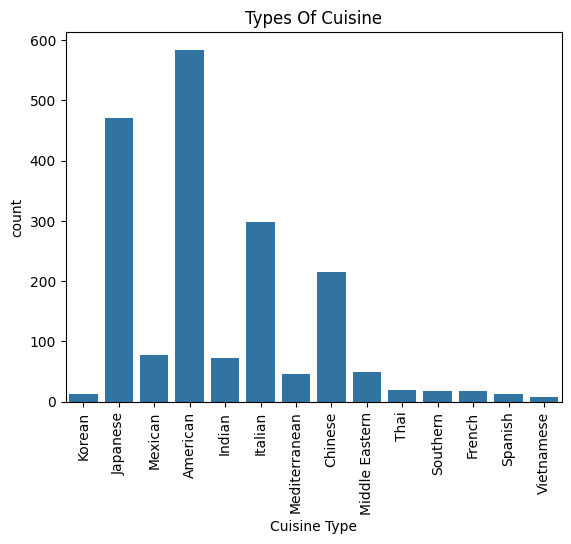

In [20]:
# Creating some visualizations for 'cuisine_type'.

sns.countplot(data = df, x = 'cuisine_type');
plt.xticks(rotation = 90);
plt.title('Types Of Cuisine');
plt.xlabel('Cuisine Type');


* American (31%) and Japanese (25%) are the most common types of cuisine, followed by Italian (16%) and Chinese (11%)

In [21]:
# Verify percentage for each cuisine type.

df['cuisine_type'].value_counts(normalize=True)

cuisine_type
American          0.307692
Japanese          0.247629
Italian           0.157007
Chinese           0.113277
Mexican           0.040569
Indian            0.038462
Middle Eastern    0.025817
Mediterranean     0.024236
Thai              0.010011
French            0.009484
Southern          0.008957
Korean            0.006849
Spanish           0.006322
Vietnamese        0.003688
Name: proportion, dtype: float64

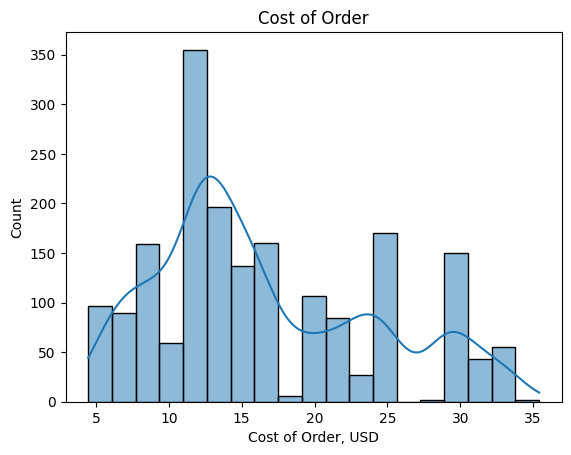

In [22]:
# The next variable in the analysis is 'cost_of_the_order', which is numeric.  Creating both an histogram and a box plot.

sns.histplot(data = df, x = 'cost_of_the_order', kde = True);
plt.title('Cost of Order');
plt.xlabel('Cost of Order, USD');

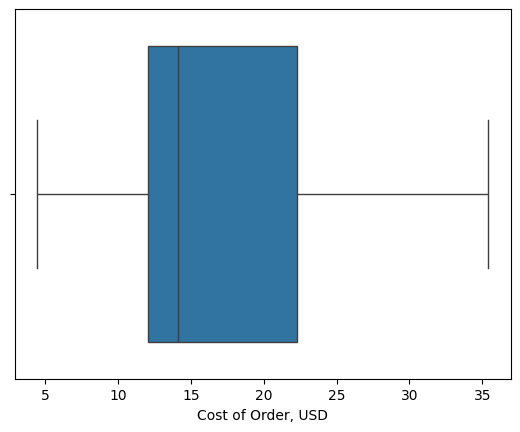

In [23]:
# Creating the box plot for 'cost_of_the_order'.

sns.boxplot(data = df, x = 'cost_of_the_order');
plt.xlabel('Cost of Order, USD');

* There are no outliers in 'cost_of_order'
* The distribution is right skewed (positive skewed)
* 50% of the orders cost less than 15 USD (it is assumed that the currency used is USD as data is from New York, USA)

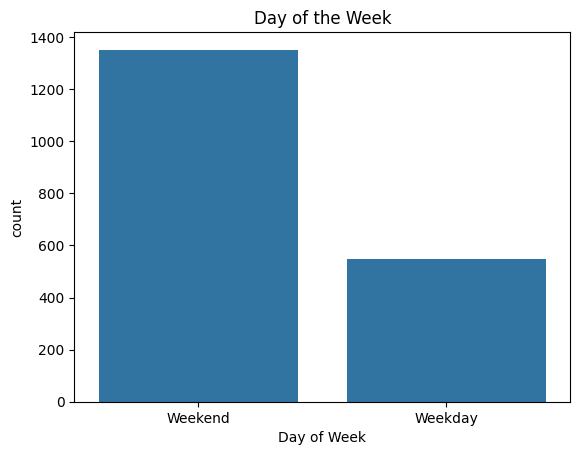

In [24]:
# The next variable 'day_of_the_week' is categorical. Creating a bar graph.

sns.countplot(data = df, x = 'day_of_the_week');
plt.title('Day of the Week');
plt.xlabel('Day of Week');

In [25]:
# Verify percentage for day of the week.

df['day_of_the_week'].value_counts(normalize=True)

day_of_the_week
Weekend    0.711802
Weekday    0.288198
Name: proportion, dtype: float64

* Weekends are most predominant (71%), than weekdays (29%)

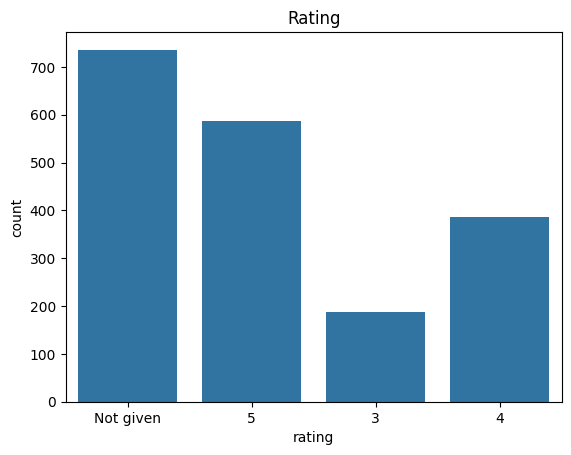

In [26]:
# The next variable 'rating' is categorical. Creating a bar graph.

sns.countplot(data = df, x = 'rating');
plt.title('Rating');

In [27]:
# Verify percentage for rating.

df['rating'].value_counts(normalize=True)

rating
Not given    0.387777
5            0.309800
4            0.203372
3            0.099052
Name: proportion, dtype: float64

* Not given (not rated) is 39%, a rating of '5' happened 31%, a rating of '4' 20%, and a rating of '3' 10%
* There are no ratings of '2' or '1'

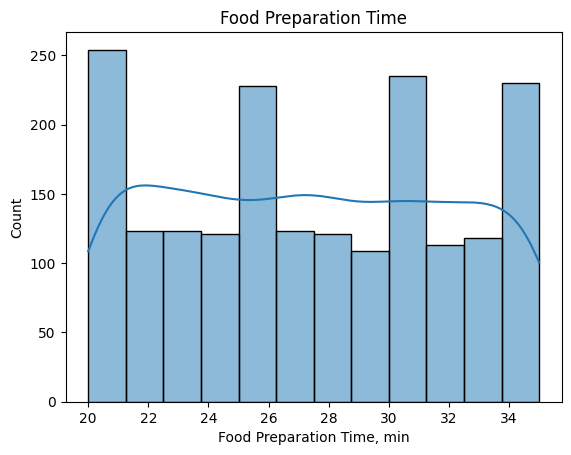

In [28]:
# The next variable in the analysis is 'food_preparation_time', which is numeric.  Creating both an histogram and a box plot.

sns.histplot(data = df, x = 'food_preparation_time', kde = True);
plt.title('Food Preparation Time');
plt.xlabel('Food Preparation Time, min');

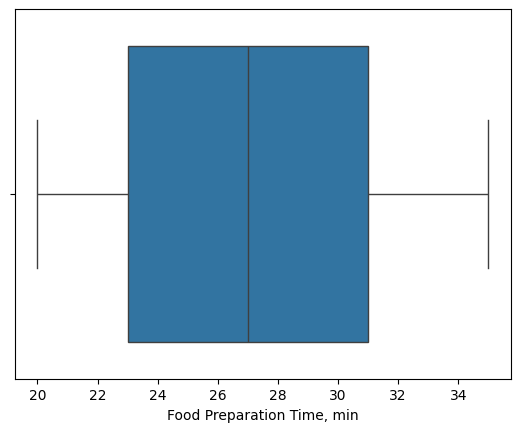

In [29]:
# Creating the box plot for 'food_preparation_time'.

sns.boxplot(data = df, x = 'food_preparation_time');
plt.xlabel('Food Preparation Time, min');

* Food preparation time is almost symmetrical as mean is very close to median (27.4 to 27), but is not a normal distribution.
* There are no outliers

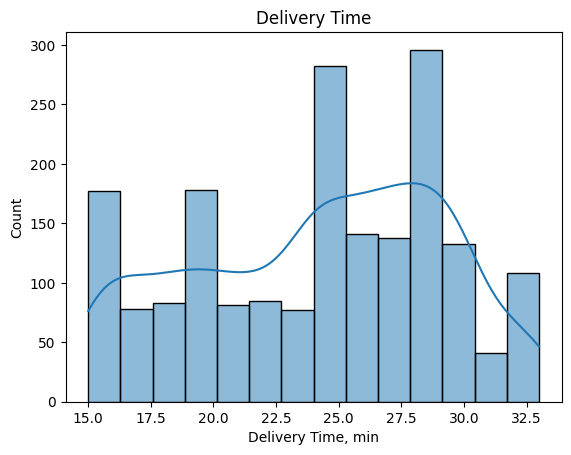

In [30]:
# The last variable in the analysis is 'delivery_time', which is numeric.  Creating both an histogram and a box plot.

sns.histplot(data = df, x = 'delivery_time', kde = True);
plt.title('Delivery Time');
plt.xlabel('Delivery Time, min');

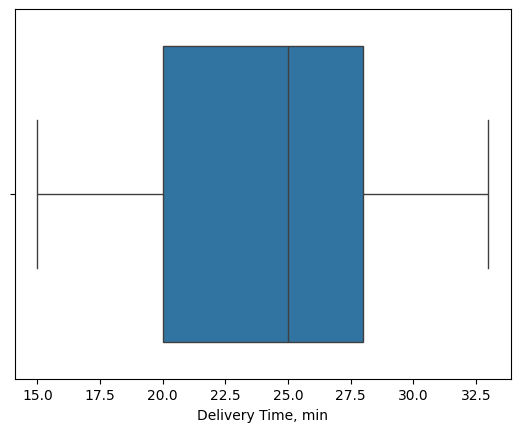

In [31]:
# Creating the box plot for 'delivery_time'.

sns.boxplot(data = df, x = 'delivery_time');
plt.xlabel('Delivery Time, min');

* The distribution is lightly left skewed
* There are no outliers
* 50% of the deliveries take between 15 and less than 25 minutes

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [32]:
# Write the code here

df[['restaurant_name', 'cuisine_type']].value_counts().head(5)

restaurant_name            cuisine_type
Shake Shack                American        219
Blue Ribbon Sushi          Japanese        119
The Meatball Shop          Italian         112
Blue Ribbon Fried Chicken  American         96
Parm                       Italian          68
Name: count, dtype: int64

#### Observations:

* The top 5 restaurants in orders received are: Shake Shack (219 orders), The Meatball Shop (132 orders), Blue Ribbon Sushi (119 orders), Blue Ribbon Fried Chicken (96 orders) and Parm (68 orders)
* This is also reflected in the most popular types of cuisine found earlier: American, Japanese, and Italian.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [33]:
# Write the code here

df_weekends = df[df['day_of_the_week'] == 'Weekend']
df_weekends['cuisine_type'].value_counts(normalize = True).head(3)

cuisine_type
American    0.307180
Japanese    0.247964
Italian     0.153220
Name: proportion, dtype: float64

#### Observations:

* The most popular cuisine on weekends is American (31%)

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [34]:
# Write the code here

# Find orders that cost above 20 USD.
df_above_20 = df[df['cost_of_the_order'] > 20]

# Calculate percentage.
percentage = (df_above_20.shape[0] / df.shape[0]) * 100

print(percentage)

29.24130663856691


#### Observations:

* Around 29.24% of the orders cost more than 20 USD

### **Question 10**: What is the mean order delivery time? [1 mark]

In [35]:
# Write the code here

df['delivery_time'].mean()

np.float64(24.161749209694417)

#### Observations:

* The average order delivery time is 24.16 minutes {also can be verified earlier with df.describe()}

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [36]:
# Write the code here

df['customer_id'].value_counts().head(3)

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64

#### Observations:

* The most frequent customers are (by Customer Id.): '52832' with 13 purchases, '47440' with 10 purchases and '83287' with 9 purchases


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


In [37]:
# Write the code here

'''  
There are 5 numerical variables, of which neither 'customer_id' nor 'order_id' add any value to the analysis.

From the univariate analysis, 698 customers placed at least an additional order (1898 - 1200).

The categorical variable 'restaurant_name' will not be used in the multivariate analysis.

For the multivariate analysis the numerical variables to be used are: 'cost_of_the_order', 'food_preparation_time' and 'delivery_time'.

'''

"  \nThere are 5 numerical variables, of which neither 'customer_id' nor 'order_id' add any value to the analysis.\n\nFrom the univariate analysis, 698 customers placed at least an additional order (1898 - 1200).\n\nThe categorical variable 'restaurant_name' will not be used in the multivariate analysis.\n\nFor the multivariate analysis the numerical variables to be used are: 'cost_of_the_order', 'food_preparation_time' and 'delivery_time'.\n\n"

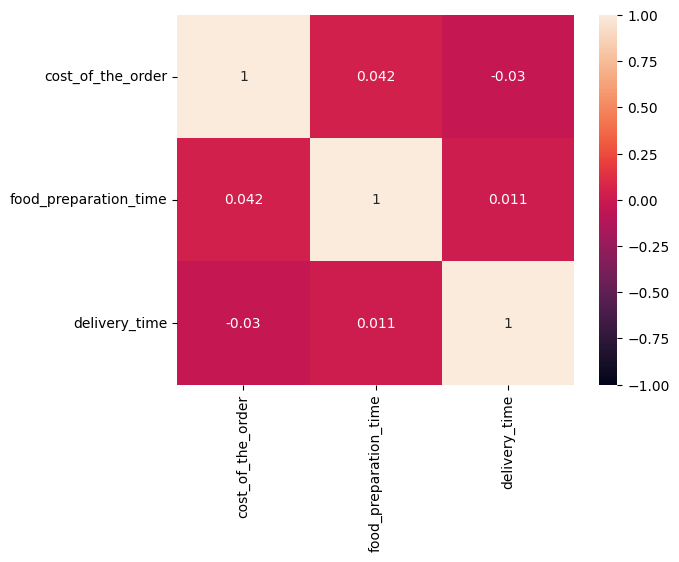

In [38]:
# Create a heatmap to study the correlation between numerical variables.

sns.heatmap(df[['cost_of_the_order', 'food_preparation_time', 'delivery_time']].corr(), vmin=-1, vmax=1, annot=True);

* There is no correlation (very low, near 0) between the numerical variables. They could be considered independent, as for example food preparation time has no effect on delivery time nor on cost of the order, and vice versa.

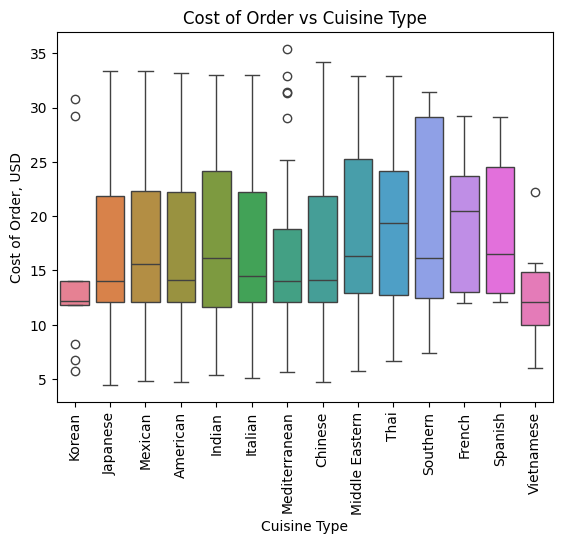

In [39]:
# Creating a boxplot to view relationship between Cuisine Type and Cost of Order, using Cuisine Type as hue to make more easy to read

sns.boxplot(data = df, x = 'cuisine_type', y = 'cost_of_the_order', hue = 'cuisine_type');
plt.xticks(rotation = 90);
plt.title('Cost of Order vs Cuisine Type');
plt.ylabel('Cost of Order, USD');
plt.xlabel('Cuisine Type');

* The most popular cuisines American, Japanese, Italian and Chinese have very similar boxplots.
* Korean, Mediterranean and Vietnamese have outliers.

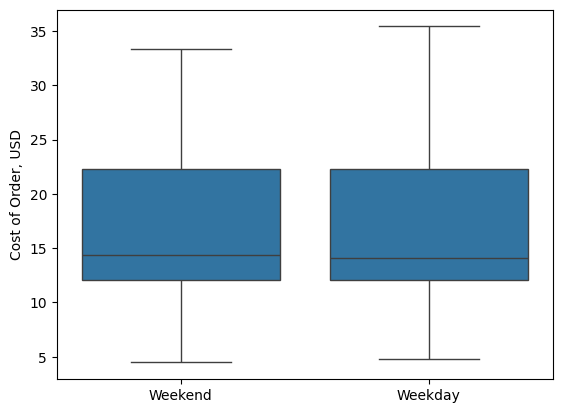

In [40]:
# Creating a boxplot to view relationship between Cost of the Order and Day of the Week.

sns.boxplot(data= df, x = 'day_of_the_week', y ='cost_of_the_order');
plt.ylabel('Cost of Order, USD');
plt.xlabel('');

* Both figures are very similar, with Weekday having a slightly longer upper whisker.
* There are no outliers.

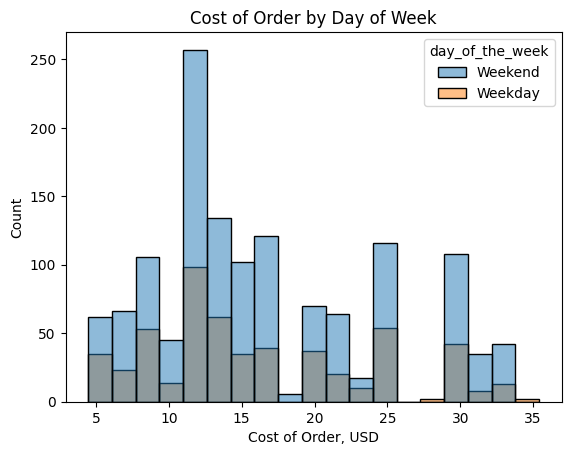

In [41]:
# Creating a Histogram for Cost of the Order, using Day of the Week as hue.

sns.histplot(data=df, x = 'cost_of_the_order', hue = 'day_of_the_week');
plt.title('Cost of Order by Day of Week');
plt.xlabel('Cost of Order, USD');

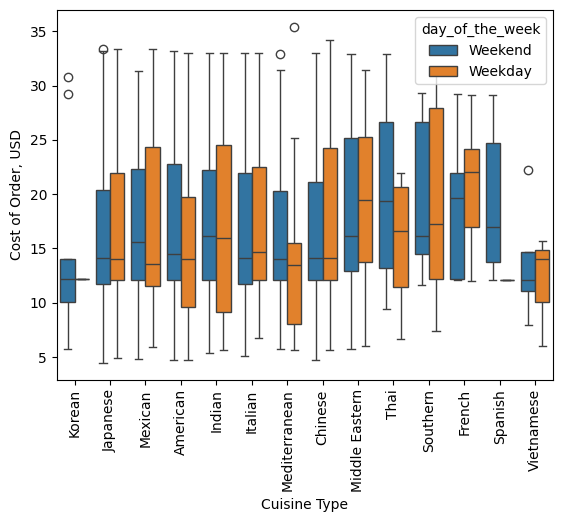

In [42]:
# Creating a boxplot to view relationship between Cuisine Type and Cost of Order, using Day of the Week as hue for comparison.

sns.boxplot(data = df, x = 'cuisine_type', y = 'cost_of_the_order', hue = 'day_of_the_week');
plt.xticks(rotation = 90);
plt.ylabel('Cost of Order, USD');
plt.xlabel('Cuisine Type');

* Korean, Japanese, Mediterranean and Vietnamese have outliers on Weekends.
* Mediterranean have an outlier on Weekday that may be related to the enlogated whisker on the box plot of Cost of The Order and Day of the Week.

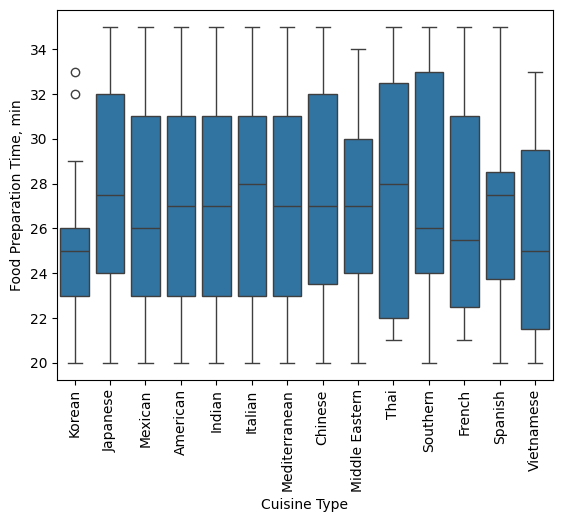

In [43]:
# Creating a boxplot to view relationship between Cuisine Type and Food Preparation Time.

sns.boxplot(data = df, x = 'cuisine_type', y = 'food_preparation_time');
plt.xticks(rotation = 90);
plt.ylabel('Food Preparation Time, min');
plt.xlabel('Cuisine Type');

* Korean Cuisine have outliers.

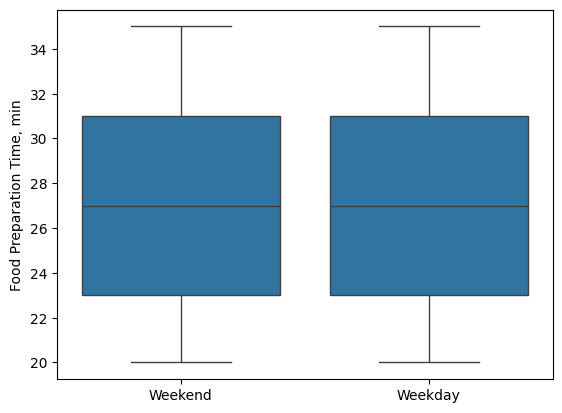

In [44]:
# Creating a boxplot to view relationship between Food Preparation Time and Day of the Week.

sns.boxplot(data = df, x = 'day_of_the_week', y = 'food_preparation_time');
plt.ylabel('Food Preparation Time, min');
plt.xlabel('');

* Both graphs are almost identical.
* There are no outliers.

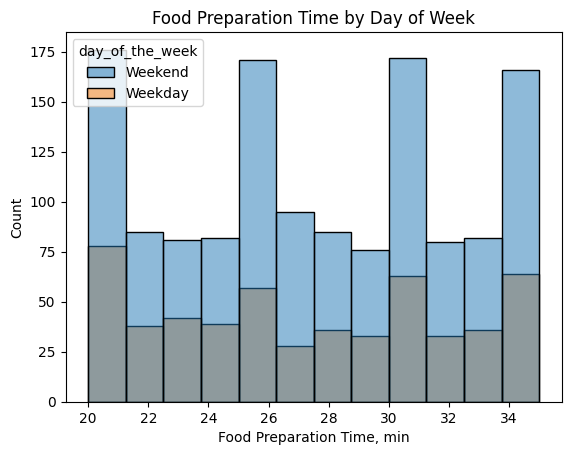

In [45]:
# Creating a Histogram for Food Preparation Time, using Day of the Week as hue

sns.histplot(data=df, x = 'food_preparation_time', hue = 'day_of_the_week');
plt.title('Food Preparation Time by Day of Week');
plt.xlabel('Food Preparation Time, min');

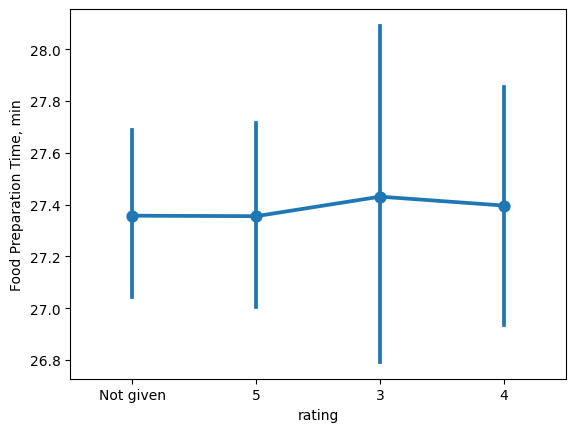

In [46]:
# Creating a pointplot to view relationship between Food Preparation Time and Rating.

sns.pointplot(data = df, x = 'rating', y = 'food_preparation_time');
plt.ylabel('Food Preparation Time, min');

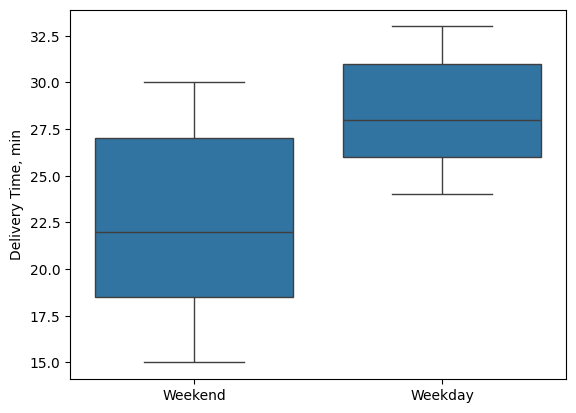

In [47]:
# Creating a boxplot to view relationship between Delivery Time and Day of the Week.

sns.boxplot(data = df, x = 'day_of_the_week', y = 'delivery_time');
plt.ylabel('Delivery Time, min');
plt.xlabel('');

* Delivery time takes longer on Weekdays.
* There are no outliers.

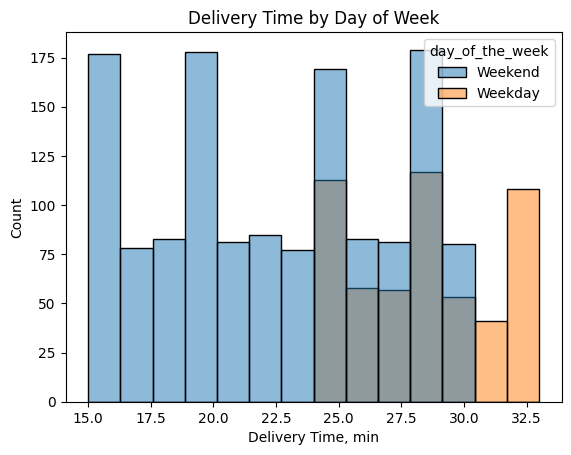

In [48]:
# Creating a Histogram for Delivery Time, using Day of the Week as hue

sns.histplot(data=df, x = 'delivery_time', hue = 'day_of_the_week');
plt.title('Delivery Time by Day of Week');
plt.xlabel('Delivery Time, min');

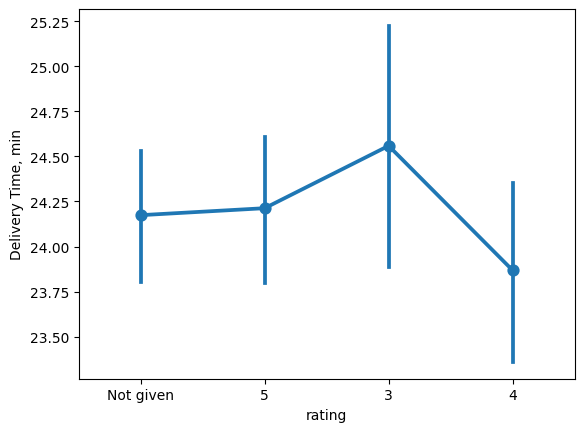

In [49]:
# Creating a pointplot to view relationship between Delivery Time and Rating.

sns.pointplot(data = df, x = 'rating', y = 'delivery_time');
plt.ylabel('Delivery Time, min');

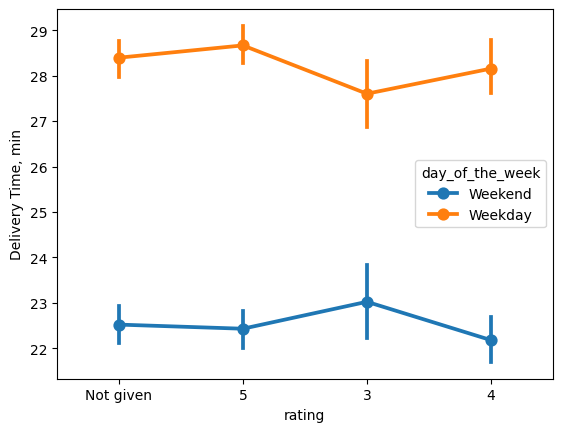

In [50]:
# Creating a pointplot to view relationship between Delivery Time and Rating, with Day of the Week as hue.

sns.pointplot(data = df, x = 'rating', y = 'delivery_time', hue='day_of_the_week');
plt.ylabel('Delivery Time, min');

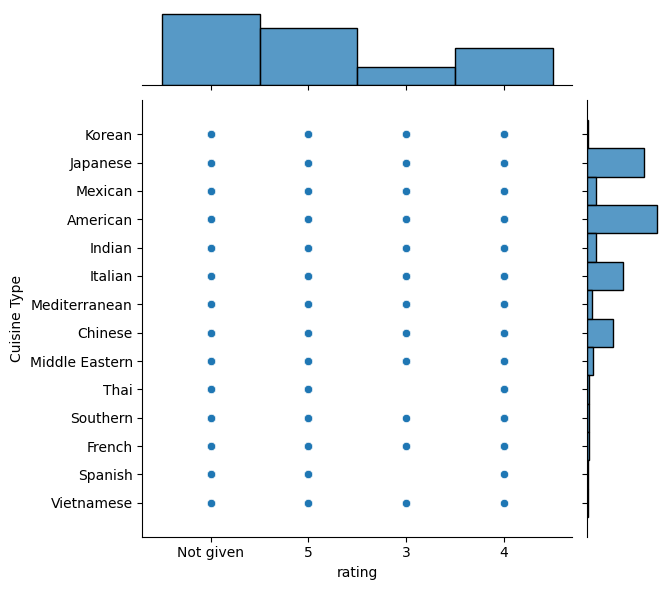

In [51]:
# Creating a jointplot to view relationship between Cuisine Type and Rating.

sns.jointplot(data=df, x= 'rating', y= 'cuisine_type');
plt.ylabel('Cuisine Type');

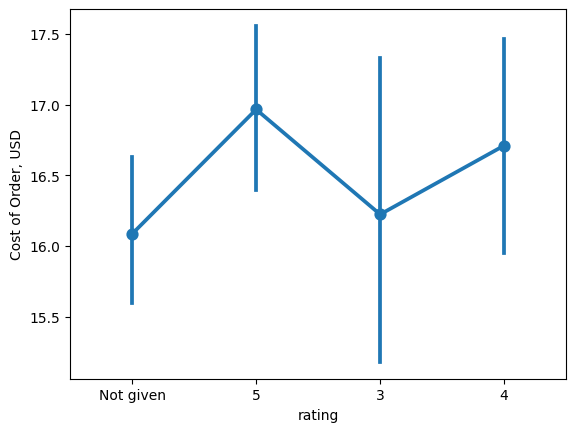

In [52]:
# Creating a pointplot to view relationship between Cost of the Order and Rating.

sns.pointplot(data = df, x = 'rating', y = 'cost_of_the_order');
plt.ylabel('Cost of Order, USD');

* Ratings of '5' and '4' are likely given to expensive orders.

### Additional Analysis

In [53]:
# Calculating the total revenue for the restaurants.

df['cost_of_the_order'].sum()

np.float64(31314.82)

In [54]:
# Calculating the total revenue per restaurant for the top 10.

df.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending = False).head(10)

restaurant_name
Shake Shack                      3579.53
The Meatball Shop                2145.21
Blue Ribbon Sushi                1903.95
Blue Ribbon Fried Chicken        1662.29
Parm                             1112.76
RedFarm Broadway                  965.13
RedFarm Hudson                    921.21
TAO                               834.50
Han Dynasty                       755.29
Blue Ribbon Sushi Bar & Grill     666.62
Name: cost_of_the_order, dtype: float64

In [55]:
# Calculating the total revenue generated by each of the top 10 customers.

df.groupby(['customer_id'])['cost_of_the_order'].sum().sort_values(ascending = False).head(10)

customer_id
52832     225.80
250494    183.83
47440     158.18
276192    146.46
83287     139.31
259341    130.81
97991     122.03
82041     120.92
115213    115.40
60039     109.76
Name: cost_of_the_order, dtype: float64

In [56]:
# Getting a general glimpse of the ratings by customer.

df.groupby(['customer_id'])['rating'].count().sort_values(ascending = False)

customer_id
52832     13
47440     10
83287      9
250494     8
65009      7
          ..
58205      1
390232     1
390436     1
390459     1
5139       1
Name: rating, Length: 1200, dtype: int64

In [57]:
# Getting a general glimpse of the most common ratings by customer.

df.groupby(['customer_id'])['rating'].value_counts().sort_values(ascending = False)

customer_id  rating   
52832        Not given    6
65009        5            5
83287        Not given    5
60052        5            4
47440        4            4
                         ..
390484       4            1
390490       3            1
391746       4            1
49034        Not given    1
385191       5            1
Name: count, Length: 1609, dtype: int64

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [58]:
# Write the code here

# Create a dataset of restaurants with ratings other than 'Not given'
df_rated_restaurants = df[df['rating'] != 'Not given'].copy()

# As rating is casted as 'object' and the values are just 3, 4 and 5; convert to integers
df_rated_restaurants['rating'] = df_rated_restaurants['rating'].astype('int')

# Create a dataframe that contains the restaurant names with their rating counts, and reset the index
df_rating_count = df_rated_restaurants.groupby(['restaurant_name'])['rating'].count().sort_values(ascending = False).reset_index()

# Create a list of names of reataurants that have rating count more than 50
restaurants_with_rating_over_50 = df_rating_count[df_rating_count['rating'] > 50]['restaurant_name']

# Create a DataFrame of the restaurants from rated restaurants, using restaurants_with_rating_over_50 as filter
df_rating_over_50 = df_rated_restaurants[df_rated_restaurants['restaurant_name'].isin(restaurants_with_rating_over_50)].copy()

# Group the restaurant names with their ratings and find the average rating of each restaurant,and reseting the index
df_average_rating = df_rating_over_50.groupby(['restaurant_name'])['rating'].mean().sort_values(ascending = False).reset_index().dropna()

# filter for average rating greater than 4, and reseting index if necessary
df_average_rating_greater_than_4 = df_average_rating[df_average_rating['rating'] > 4].sort_values(by='rating', ascending=False).reset_index(drop=True)

print(df_average_rating_greater_than_4)

             restaurant_name    rating
0          The Meatball Shop  4.511905
1  Blue Ribbon Fried Chicken  4.328125
2                Shake Shack  4.278195
3          Blue Ribbon Sushi  4.219178


#### Observations:

* The restaurants with more than 50 reviews (ratings) and with average ratings more than 4, that qualify for the promotion are:
        The Meatball Shop (4.5), Blue Ribbon Fried Chicken (4.3), Shake Shack (4.3), and Blue Ribbon Sushi (4.2)
* The 4 restaurants were previously identified in the Top 5 Restaurants in terms of number of orders received. 

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [59]:
# Write the code here

# Inserting a new column in the DataFrame, with the charges calculated using a lambda function.

df['company_revenue'] = df['cost_of_the_order'].apply(lambda x: x*0.25 if x > 20 else (x*0.15 if x > 5 else x*0))

net_revenue = df['company_revenue'].sum()

print(net_revenue)

6166.303


#### Observations:

* The net revenue generated by the company across all orders is $6,166.30 USD.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [60]:
# Write the code here

# Insert a new column in the DataFrame that is the sum of preparation and delivery times.
df['prep_and_deliver'] = df['food_preparation_time'] + df['delivery_time']

# Filter for orders with more than 60 min.

df_more_than_60_min = df[df['prep_and_deliver'] > 60]

# Calculate percentage.
percentage = (df_more_than_60_min.shape[0] / df.shape[0]) * 100

print(percentage)

10.537407797681771


#### Observations:

* Around 10.54% of the orders take more than 60 minutes to get delivered from the time the order is placed.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [61]:
# Write the code here

# Get the mean delivery time on weekdays and weekends

mean_delivery_time_weekdays = round(df[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean())

mean_delivery_time_weekends = round(df[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean())

print('The average delivery time on weekdays is:', mean_delivery_time_weekdays, 'and on weekends is:', mean_delivery_time_weekends)


The average delivery time on weekdays is: 28 and on weekends is: 22


#### Observations:
* The mean delivery time on weekends, 22 minutes is smaller (faster) than on weekdays, 28 minutes.
* From the univariate analysis is important to consider that around 70% of the orders are placed on weekends.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  In the dataset there are: 1898 placed orders, 1200 registered users (customers), 178 registered restaurants and 14 types of cuisine.
*  Of the 1200 users, 698 placed at least a second order. That means that 502 users (42%) have used the application just 1 time. This could be important for later calculate values such as churn and user retention.
*  The total revenue for the restaurants was 31,314.82 USD. The restaurant with most revenue was Shake Shack with 3,579.53 USD from 219 orders.  This also helped American cuisine to become the most popular type.
*  Average and median costs of the orders are 16.5 and 14 USD, so the company will be frequently applying the 15% rate.
*  Expected company revenue is 6,166.30 USD.
*  Orders placement on weekends (Saturday and Sunday) is almost 2.5 times that of weekdays (Monday through Friday).
*  Delivery on weekends is faster, even with the increased volumen.
*  1162 of the orders were rated between '3' and '5' (there were no ratings of '1' or '2'), 736 were not rated ('Not given').

### Recommendations:

*  On taking advantage of increased demand on weekends:

Data shows that usage of the application more than doubles during weekends, so is recommended that the company ensures there are enough resources (mainly delivery personnel) to cover that increase in demand, while keeping low delivery times. Also is a good opportunity for implementing a "dynamic pricing", or surge pricing policy.
 
As most of the orders are in the 5 - 20 USD, the company may consider increasing its rate for that segment during weekends.  

For example applying a rate from 15% to 18% could increase company revenue near 6%, and this could be used not only to have more resources available during that time, but also to cover the potential increase in orders under 5 USD, for which the company does not receive any revenue but still has to provide delivery personnel.

In [62]:
# Calculating benefits for a "dynamic pricing" or surge pricing policy on weekends, increasing from 15% to 18% charge on orders costing between 5 and 20 USD.

df['company_revenue_weekends'] = df_weekends['cost_of_the_order'].apply(lambda x: x*0.25 if x > 20 else (x*0.15 if x > 5 else x*0.0))

normal_weekend_revenue = df['company_revenue_weekends'].sum()

df['company_revenue_weekends'] = df_weekends['cost_of_the_order'].apply(lambda x: x*0.25 if x > 20 else (x*0.18 if x > 5 else x*0.0))

surge_weekend_revenue = df['company_revenue_weekends'].sum()

print(f'Increase in revenue: {(surge_weekend_revenue - normal_weekend_revenue):.2f} USD')

Increase in revenue: 353.37 USD


*  On ranking and user engagement:

Tools like surveys, questionarires and ranking are very useful to companies for getting feedback from their customers in order to identify problems or improvement opportunities, but people usually complete these tools without paying attention, with random answers or expected responses, so the end result could be a poor or misleading feedback.

In general for this application, the user journey starts with placing the order, checking the status, receiving the food and consuming the food.  It is after the final step that the user will develop a better idea of his / her level of satisfaction.  The question then is if he / she will have the motivation or drive to open the application again and rank the experience?

From the data there are a lot of ratings 'Not given', high amount of '5' ratings, no '1' or '2' ratings so it is difficult to identify "pain points" of users (it is fairly uncommon that all users are positevely happy, and impossible to differentiate if these rankings apply to application features, satisfaction for experience / service, quality of food, etc.).

Using as an example the customer with 13 purchases, his/her number of 'Not given' are 6, which is almost half the times the application was used.

It is recommended to improve the ranking system by introducing an incentive to increase user engagement, and get more and detailed feedback that can be used later with other techniques such as sentiment analysis. One way to do this is by linking the ranking to a blog where the user can write about his / her experience with the application and the food, post pictures, and see other users' reviews and recommendations.  This could create a community of more engaged users, offer more visibility (advertising) to the restaurants, collect more 'honest' user feedback, and identify additional opportunities for monetization (for example different categories with reward points programs).


---

Disclaimer: this notebook uses some of the code and structure from PYF_Project_Learner_Low_Code.ipynb. and some AI generated recommendations (for code) from Goggle Colab.